<a href="https://colab.research.google.com/github/chlwnsdud0125/2026_bigdatacomputing_20230613/blob/main/%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC_%EA%B3%BC%EC%A0%9C_20230613_%EC%B5%9C%EC%A4%80%EC%98%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 39.2 MB/s eta 0:00:00


In [25]:
# 데이터 전처리, 파이프라인 학습 및 모델 저장
import pandas as pd # 데이터 프레임(표)을 다루기 위한 라이브러리
import numpy as np # 숫자 연산과 랜덤 추출을 위한 라이브러리
import joblib # 학습이 끝난 모델을 파일로 저장해 주는 라이브러리
from sklearn.pipeline import Pipeline # 전처리와 학습 과정을 한 줄로 예쁘게 묶어주는 도구
from sklearn.preprocessing import StandardScaler, PolynomialFeatures # 데이터 크기 맞추기 및 변수 (다항) 도구
from sklearn.linear_model import LinearRegression, Ridge # 기본 선형 회귀와 규제가 들어간 릿지 모델
from sklearn.model_selection import train_test_split # 데이터를 학습용/시험용으로 나누는 도구
from sklearn.metrics import r2_score, mean_squared_error # 모델 채점표 (R^2, MSE) 도구

# 1. 데이터 로드 및 결측치 제거
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url) # 인터넷에서 CSV 파일 읽어오기
df = df.dropna() # 결측치 제거


features = ['Adult mortality', 'BMI', 'GDP'] # 3가지 데이터(문제지)
target = 'Life expectancy'  #  최종적으로 예측할 기대수명(정답지)

X = df[features] # 문제지 세팅
y = df[target] # 정답지 세팅

# 2. 데이터 분할 및 소규모 훈련 샘플링 (50개)
# 전체 데이터를 8:2 비율로 학습용(Train)과 시험용(Test)으로 나눔
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 과대적합(Overfitting)을 일부러 유도하려고 공부할 데이터를 딱 50개만 랜덤 추출
np.random.seed(42) #  결과가 안 바뀌게 시드 고정
sample_indices = np.random.choice(X_train_full.shape[0], size=50, replace=False) # 50개 번호표 뽑기
X_train = X_train_full.iloc[sample_indices] # 훈련 문제지 50장
y_train = y_train_full.iloc[sample_indices] # 훈련 정답지 50장

print(f"데이터 준비 완료: 훈련용 샘플 {X_train.shape[0]}개, 테스트용 {X_test.shape[0]}개")

# 3. 모델 파이프라인 3종 정의
pipelines = {
    "Linear": Pipeline([ # 1번: 평범한 기본 선형 회귀 모델
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]),
    "Poly": Pipeline([ # 2번: 변수를 3차원으로 바꿔서 엄청 복잡하게 만든 모델 (과대적합 됨)
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3)),
        ("reg", LinearRegression())
    ]),
    "Ridge": Pipeline([ # 3번: 복잡하지만 릿지(Ridge) 규제 적용
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3)),
        ("reg", Ridge(alpha=1.0, random_state=42))
    ])
}

evaluation_summary = {} # 각 모델의 성적표를 담을 빈 상자 준비

print("  파이프라인 모델 학습 및 성능 평가 시작")

# 4. 모델 학습 및 평가
for name, pipeline in pipelines.items(): # 3개의 파이프라인을 순서대로 하나씩 꺼냄
    # 50개 샘플로 모델 학습시키기
    pipeline.fit(X_train, y_train)

    # 예측
    y_train_pred = pipeline.predict(X_train) # Train 예측
    y_test_pred = pipeline.predict(X_test)   # Test 예측

    # 평가지표 산출
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # 특성 복잡도: Poly 변환을 거치고 난 뒤 특성(힌트)의 개수가 몇 개로 불어났는지 확인
    complexity = pipeline[:-1].transform(X_train.iloc[0:1]).shape[1]

    # 위에서 계산한 점수들을 딕셔너리에 기록
    evaluation_summary[name] = {
        "train_r2": train_r2,
        "test_r2": test_r2,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "complexity": complexity
    }

    print(f" [{name}] 파이프라인 완료 | 복잡도(특성수): {complexity} | Test R^2: {test_r2:.4f}")

# 5. 모델 및 메타데이터 저장
# 웹 대시보드(app.py)로 보내기 위해 모델 3개, 성적표, 변수 이름을 하나의 payload로 묶음
payload = {
    "models": pipelines,
    "cv_results": evaluation_summary,
    "features": features
}

# joblib을 사용해 "life_expectancy_models.pkl"이라는 파일로 디스크에 저장
joblib.dump(payload, "life_expectancy_models.pkl")
print(" 'life_expectancy_models.pkl' 파일에 성공적으로 저장되었습니다.")

데이터 준비 완료: 훈련용 샘플 50개, 테스트용 330개
  파이프라인 모델 학습 및 성능 평가 시작
 [Linear] 파이프라인 완료 | 복잡도(특성수): 3 | Test R^2: 0.5702
 [Poly] 파이프라인 완료 | 복잡도(특성수): 20 | Test R^2: -4.9030
 [Ridge] 파이프라인 완료 | 복잡도(특성수): 20 | Test R^2: 0.6386
 'life_expectancy_models.pkl' 파일에 성공적으로 저장되었습니다.


In [27]:
# Streamlit 대시보드 (app.py)
import streamlit as st # 웹 화면을 만드는 핵심 라이브러리
import numpy as np # 숫자 계산 도구
import joblib # 학습된 모델 파일(.pkl)을 불러오는 도구
import pandas as pd # 표(테이블)를 다루는 도구
import matplotlib.pyplot as plt # 그래프 그리는 도구

# 웹 화면 설정을 와이드하게 설정
st.set_page_config(page_title="기대수명 예측 파이프라인", layout="wide")

# 대시보드 제목과 설명 문구 출력
st.title("🌍 WHO 기대수명 다중 회귀 예측 대시보드")
st.write("선형 회귀, 다항 회귀, 릿지(Ridge) 규제 모델의 성능(과대적합)을 비교하고, 특성값 조절을 통해 기대수명을 실시간으로 예측합니다.")
st.markdown("---") # 가로 구분선

# 1. 모델 파일 로드
def load_model_data():
    try:
        return joblib.load("life_expectancy_models.pkl") # 저장된 모델 파일 불러오기
    except FileNotFoundError:
        st.error("⚠️ 'life_expectancy_models.pkl' 파일이 없습니다.") # 파일 없으면 에러 메시지
        return None

payload = load_model_data() # 데이터 불러오기 실행

if payload is not None: # 파일이 정상적으로 로드됐을 때 아래 기능 수행
    models = payload["models"]
    cv_results = payload["cv_results"]
    feature_names = payload["features"]

    # 모델 성능 평가 표 및 시각화 영역
    st.subheader("📊 3종 회귀 파이프라인 성능 비교 (50개 Train 샘플 기준)")

    col1, col2 = st.columns((1, 1)) # 화면을 좌우 2칸으로 나눔

    with col1: # 왼쪽 칸
        st.markdown("**1. 모델 성능 평가지표 테이블**")
        summary_data = []
        for model_name, info in cv_results.items(): # 각 모델의 성적을 하나씩 꺼냄
            summary_data.append({
                "모델명": model_name,
                "Complexity (특성 수)": info["complexity"],
                "Train R² 점수": round(info["train_r2"], 4),
                "Test R² 점수": round(info["test_r2"], 4),
                "Train MSE": round(info["train_mse"], 2),
                "Test MSE": round(info["test_mse"], 2)
            })
        df_summary = pd.DataFrame(summary_data) # 표 데이터로 변환
        st.dataframe(df_summary, use_container_width=True, hide_index=True) # 웹에 표 출력

        st.caption("ℹ️ Poly 모델의 과대적합(Overfitting) 확인 가능")

    with col2: # 오른쪽 칸
        st.markdown("**2. Test R² (결정계수) 비교 막대그래프**")
        fig, ax = plt.subplots(figsize=(6, 4)) # 그래프 그릴 준비

        names = list(cv_results.keys())
        test_r2_scores = [info["test_r2"] for info in cv_results.values()]

        colors = ['skyblue', 'salmon', 'lightgreen'] # 막대 색상 설정
        bars = ax.bar(names, test_r2_scores, color=colors) # 막대 그래프 생성

        ax.set_ylabel('Test R² Score')

        # 막대 위에 숫자 표시
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom')

        st.pyplot(fig) # 그래프를 웹 화면에 출력

    st.markdown("---")

    # 사이드바 입력 및 실시간 동적 예측 UI
    st.sidebar.header("📋 새로운 데이터 입력 (Features)")

    # 사용자가 직접 조절하는 슬라이더 생성
    input_am = st.sidebar.slider("Adult Mortality (성인 사망률)", min_value=1, max_value=750, value=150)
    input_bmi = st.sidebar.slider("BMI (체질량 지수)", min_value=1.0, max_value=90.0, value=38.0, step=0.1)
    input_gdp = st.sidebar.slider("GDP (1인당 국내총생산)", min_value=1.0, max_value=120000.0, value=5000.0, step=100.0)

    st.sidebar.markdown("---")

    # 모델 선택용 드롭다운 박스
    st.sidebar.header("⚙️ 모델 선택")
    selected_model_name = st.sidebar.selectbox(
        "예측에 사용할 파이프라인 모델을 선택하세요:",
        ("Linear", "Poly", "Ridge")
    )

    # 입력값을 모델이 이해할 수 있는 배열로 변환
    newdata = np.array([[input_am, input_bmi, input_gdp]])

    # 선택된 모델 꺼내오기
    selected_pipeline = models[selected_model_name]

    # 실시간 예측 수행 (학습된 모델이 정답을 추측)
    predicted_life = selected_pipeline.predict(newdata)[0]

    # 결과 화면 출력
    st.subheader(f"🔮 실시간 기대수명 예측 결과 [{selected_model_name} 모델]")

    # 예측값 강조 표시
    st.metric(
        label="예측된 기대수명 (Life Expectancy)",
        value=f"{predicted_life:.1f} 세",
        delta=f"선택 모델: {selected_model_name}"
    )

    st.info(f"📌 **현재 입력값** 👉 Adult Mortality: {input_am} | BMI: {input_bmi} | GDP: {input_gdp}")

2026-06-12 20:50:52.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:50:52.728 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:50:52.729 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:50:52.731 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:50:52.733 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:50:52.734 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:50:52.735 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 20:50:52.740 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [28]:
#  ngrok을 이용한 실시간 웹 배포
from pyngrok import ngrok # 외부 인터넷에서 우리 서버로 접속하게 해주는 도구
import os # 컴퓨터(OS) 명령어를 파이썬 안에서 실행하는 도구
import time # 서버가 켜질 때까지 잠시 기다려주는 시간 조절 도구

# 1. 혹시 열려있을지 모르는 기존 터널 모두 닫기 (오류 방지)
ngrok.kill()

# 2. 인증 토큰 설정 (ngrok 서비스를 이용하기 위한 개인 키)
ngrok.set_auth_token("3DyfPX5nsnteKS6tEzgTLcEspT8_akjQcgArrynFCzjXfWiY")

# 3. Streamlit 백그라운드 구동
# 8501 포트에서 app.py를 실행하고, 그 결과를 백그라운드로 보냄
os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /dev/null 2>&1 &")

# 서버가 완전히 부팅될 때까지 3초 정도 안전하게 대기
time.sleep(3)

# 4. ngrok 터널 연결 (8501 포트를 외부 인터넷 주소로 연결)
public_url = ngrok.connect(8501, bind_tls=True)

# 배포 완료 메시지 출력
print(f"✅ 성공적으로 배포되었습니다! 아래 링크를 클릭하세요:\n{public_url}")

✅ 성공적으로 배포되었습니다! 아래 링크를 클릭하세요:
NgrokTunnel: "https://ecard-proximity-fester.ngrok-free.dev" -> "http://localhost:8501"


밑에는 캡쳐화면입니다.

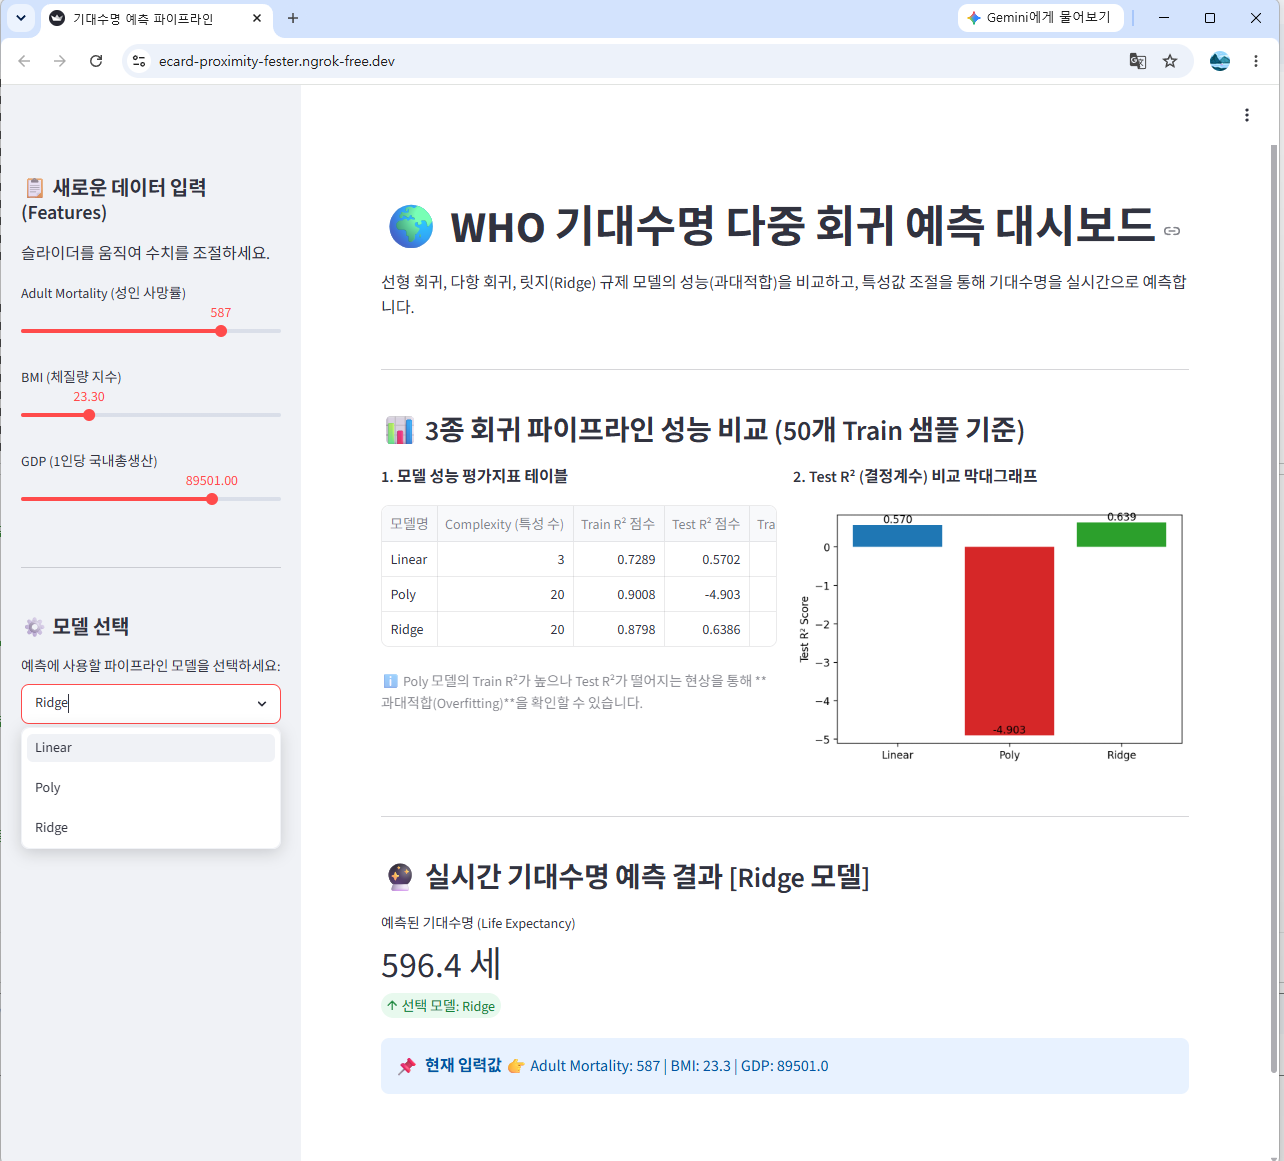